# House Price Prediction Dataset EDA

In [46]:
import pandas as pd

In [47]:
pd.set_option("display.max_columns", None)

In [48]:
df = pd.read_csv(r"../data/raw/House_Prices_Dataset.csv")

In [49]:
df.shape

(1460, 81)

In [50]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Missing Values Analysis & Data Quality Investigation

In [52]:
(df.isna().mean() * 100).sort_values(ascending=False).head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

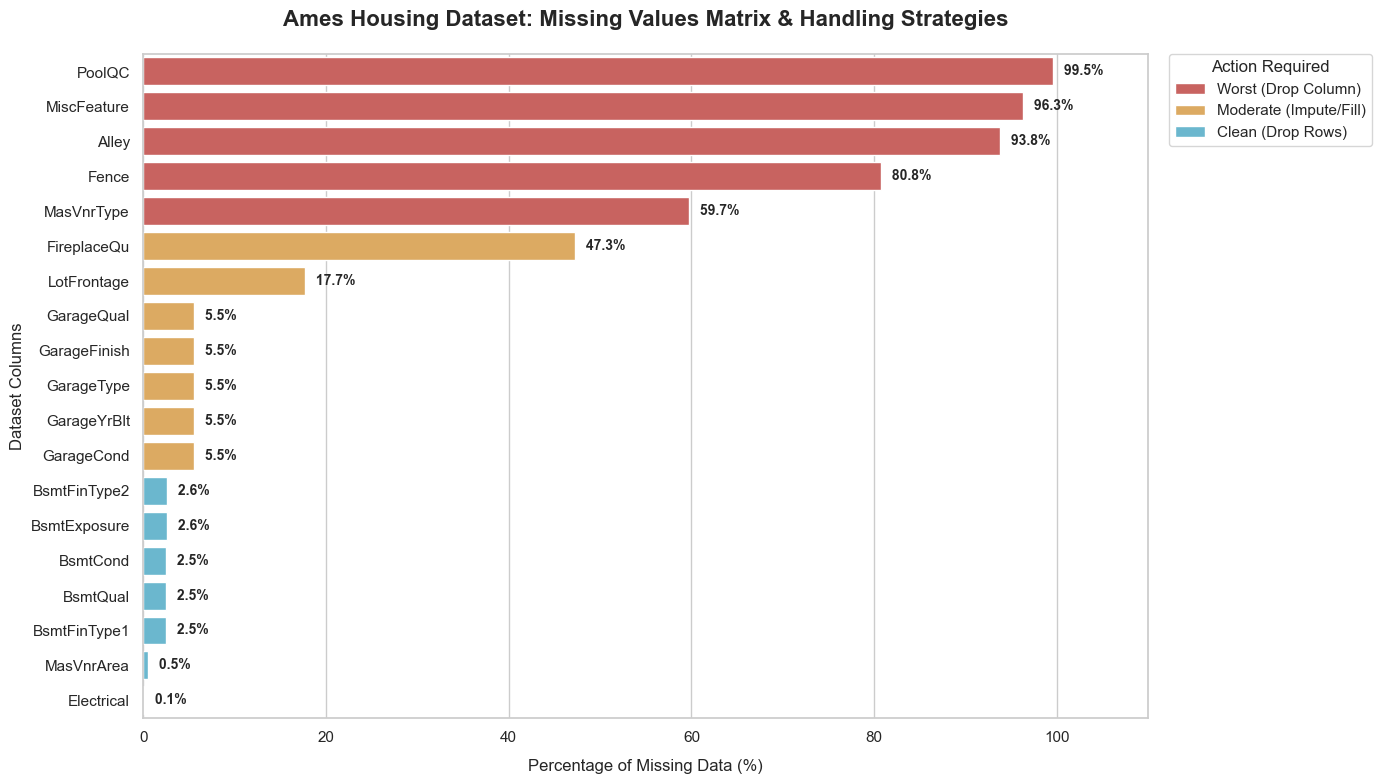

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Calculate Missing Percentages ---
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

# Convert to a DataFrame for easier plotting/manipulation
missing_df = missing_pct.reset_index()
missing_df.columns = ["Column", "MissingPercentage"]


# --- 2. Define Handling Categories & Colors ---
def assign_handling_category(pct):
    if pct > 50.0:
        return "Worst (Drop Column)"
    elif pct >= 5.0:
        return "Moderate (Impute/Fill)"
    elif pct > 0.0:
        return "Clean (Drop Rows)"
    else:
        return "Perfect (No Missing Data)"


# Apply the categorization logic
missing_df["HandlingGroup"] = missing_df["MissingPercentage"].apply(
    assign_handling_category
)

# Map distinct colors to each group for visual clarity
color_map = {
    "Worst (Drop Column)": "#d9534f",  # Muted Red
    "Moderate (Impute/Fill)": "#f0ad4e",  # Muted Yellow/Orange
    "Clean (Drop Rows)": "#5bc0de",  # Light Blue
    "Perfect (No Missing Data)": "#5cb85c",  # Muted Green
}

# --- 3. Filter out perfectly clean columns to avoid a cluttered chart ---
# We only want to plot columns that have AT LEAST some missing data
plot_df = missing_df[missing_df["MissingPercentage"] > 0]

if plot_df.empty:
    print("🎉 Congratulations! Your dataset has absolutely zero missing values.")
else:
    # --- 4. Create the Visualization ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 8))

    # Plot horizontal bars so long Ames column names are easy to read
    ax = sns.barplot(
        data=plot_df,
        x="MissingPercentage",
        y="Column",
        hue="HandlingGroup",
        palette=color_map,
        dodge=False,  # Keeps bars neatly aligned to their y-ticks
    )

    # Add numeric percentage labels to the end of each bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:  # Only label bars that have a width
            ax.annotate(
                f" {width:.1f}%",
                (width, p.get_y() + p.get_height() / 2.0),
                ha="left",
                va="center",
                fontsize=10,
                fontweight="bold",
                xytext=(5, 0),
                textcoords="offset points",
            )

    # --- 5. Polish Layout & Titles ---
    plt.title(
        "Ames Housing Dataset: Missing Values Matrix & Handling Strategies",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel("Percentage of Missing Data (%)", fontsize=12, labelpad=10)
    plt.ylabel("Dataset Columns", fontsize=12)

    # Set X axis limit slightly higher than 100 to make room for text labels
    plt.xlim(0, 110)

    # Adjust the Legend location
    plt.legend(
        title="Action Required",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=11,
        title_fontsize=12,
    )

    plt.tight_layout()
    plt.show()

- **PoolQuality:** has the most null value, this is because most house can't come with pool 
- **MiscFeature:** can also contain null values because some houses might not contain miscellanous features like (elevator, tennis court etc)
- **Alley:** some houses can also not come with alley (narrow-rear access road used for garbage collection, utility access etc)
- **MasVnrType:** some houses may not come with Masonry, so null indicate not have any masonry feature

## Handling Missing Data

**Worst columns** dropping all the columns which have null values greater than 50% of overall dataset. But i'm keeping the related column which contain numerical value. e.g: for MiscFeature it has associated column MiscVal which contain the total cost of Miscllanous feature Dollars, for null i've 0 but for other i do have cost which effect the targeted total cost of the column but for value with 0 it simply means it don't have any miscllnous feature 

In [54]:
df.drop(
    columns=[
        "PoolQC",
        "MiscFeature",
        "Alley",
        "Fence",
        "MasVnrType"
    ], inplace=True)

**Moderate columns** 

In [55]:
# filling them with None
garage_cols = [
    "FireplaceQu",
    "GarageQual",
    "GarageFinish",
    "GarageType",
    "GarageCond"
]
df[garage_cols] = df[garage_cols].fillna("None")

Filling missing LotFrontage values with the median of its specific neighborhood

In [56]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda group: group.fillna(group.median())
)

filled the garage year built with the year house was built

In [57]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

**Clean columns**

missing basement values mean "No Basement". Filled the text columns with "None"

In [58]:
bsmt_cols = [
    "BsmtFinType2",
    "BsmtExposure",
    "BsmtCond",
    "BsmtQual",
    "BsmtFinType1",
]
df[bsmt_cols] = df[bsmt_cols].fillna("None")

missing masenory values mean "No Masenory". Fill the null with 0


In [59]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

filled electrical column with most common electrical type

In [60]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

## Outlier Detection & Understanding Extreme Values

## Outlier Detection Using IQR (Interquartile Range) Method


In [61]:
# Detect outliers using IQR method
def detect_outliers_iqr(df, columns=None):
    """
    Detect outliers using Interquartile Range (IQR) method
    IQR = Q3 - Q1
    Outliers: values < Q1 - 1.5*IQR or values > Q3 + 1.5*IQR
    """
    if columns is None:
        # Get only numeric columns
        columns = df.select_dtypes(include=['float64', 'int64']).columns
    
    outlier_summary = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        if len(outliers) > 0:
            outlier_summary[col] = {
                'count': len(outliers),
                'percentage': (len(outliers) / len(df)) * 100,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'min_outlier': outliers[col].min(),
                'max_outlier': outliers[col].max()
            }
    
    return outlier_summary

# Apply IQR method
outliers_iqr = detect_outliers_iqr(df)

# Display results
print("=" * 80)
print("OUTLIER DETECTION USING IQR METHOD")
print("=" * 80)
print(f"\nTotal columns analyzed: {len(df.select_dtypes(include=['float64', 'int64']).columns)}")
print(f"Columns with outliers: {len(outliers_iqr)}\n")

for col, info in sorted(outliers_iqr.items(), key=lambda x: x[1]['count'], reverse=True):
    print(f"\n📊 {col}:")
    print(f"   Outlier Count: {info['count']} ({info['percentage']:.2f}%)")
    print(f"   Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
    print(f"   Range: {info['min_outlier']:.2f} to {info['max_outlier']:.2f}")


OUTLIER DETECTION USING IQR METHOD

Total columns analyzed: 38
Columns with outliers: 32


📊 EnclosedPorch:
   Outlier Count: 208 (14.25%)
   Bounds: [0.00, 0.00]
   Range: 19.00 to 552.00

📊 BsmtFinSF2:
   Outlier Count: 167 (11.44%)
   Bounds: [0.00, 0.00]
   Range: 28.00 to 1474.00

📊 OverallCond:
   Outlier Count: 125 (8.56%)
   Bounds: [3.50, 7.50]
   Range: 1.00 to 9.00

📊 ScreenPorch:
   Outlier Count: 116 (7.95%)
   Bounds: [0.00, 0.00]
   Range: 40.00 to 480.00

📊 MSSubClass:
   Outlier Count: 103 (7.05%)
   Bounds: [-55.00, 145.00]
   Range: 160.00 to 190.00

📊 MasVnrArea:
   Outlier Count: 98 (6.71%)
   Bounds: [-246.38, 410.62]
   Range: 412.00 to 1600.00

📊 LotFrontage:
   Outlier Count: 93 (6.37%)
   Bounds: [30.00, 110.00]
   Range: 21.00 to 313.00

📊 BsmtHalfBath:
   Outlier Count: 82 (5.62%)
   Bounds: [0.00, 0.00]
   Range: 1.00 to 2.00

📊 OpenPorchSF:
   Outlier Count: 77 (5.27%)
   Bounds: [-102.00, 170.00]
   Range: 172.00 to 547.00

📊 LotArea:
   Outlier Count: 69

## Box Plot Visualization - Top Columns with Outliers (IQR Method)

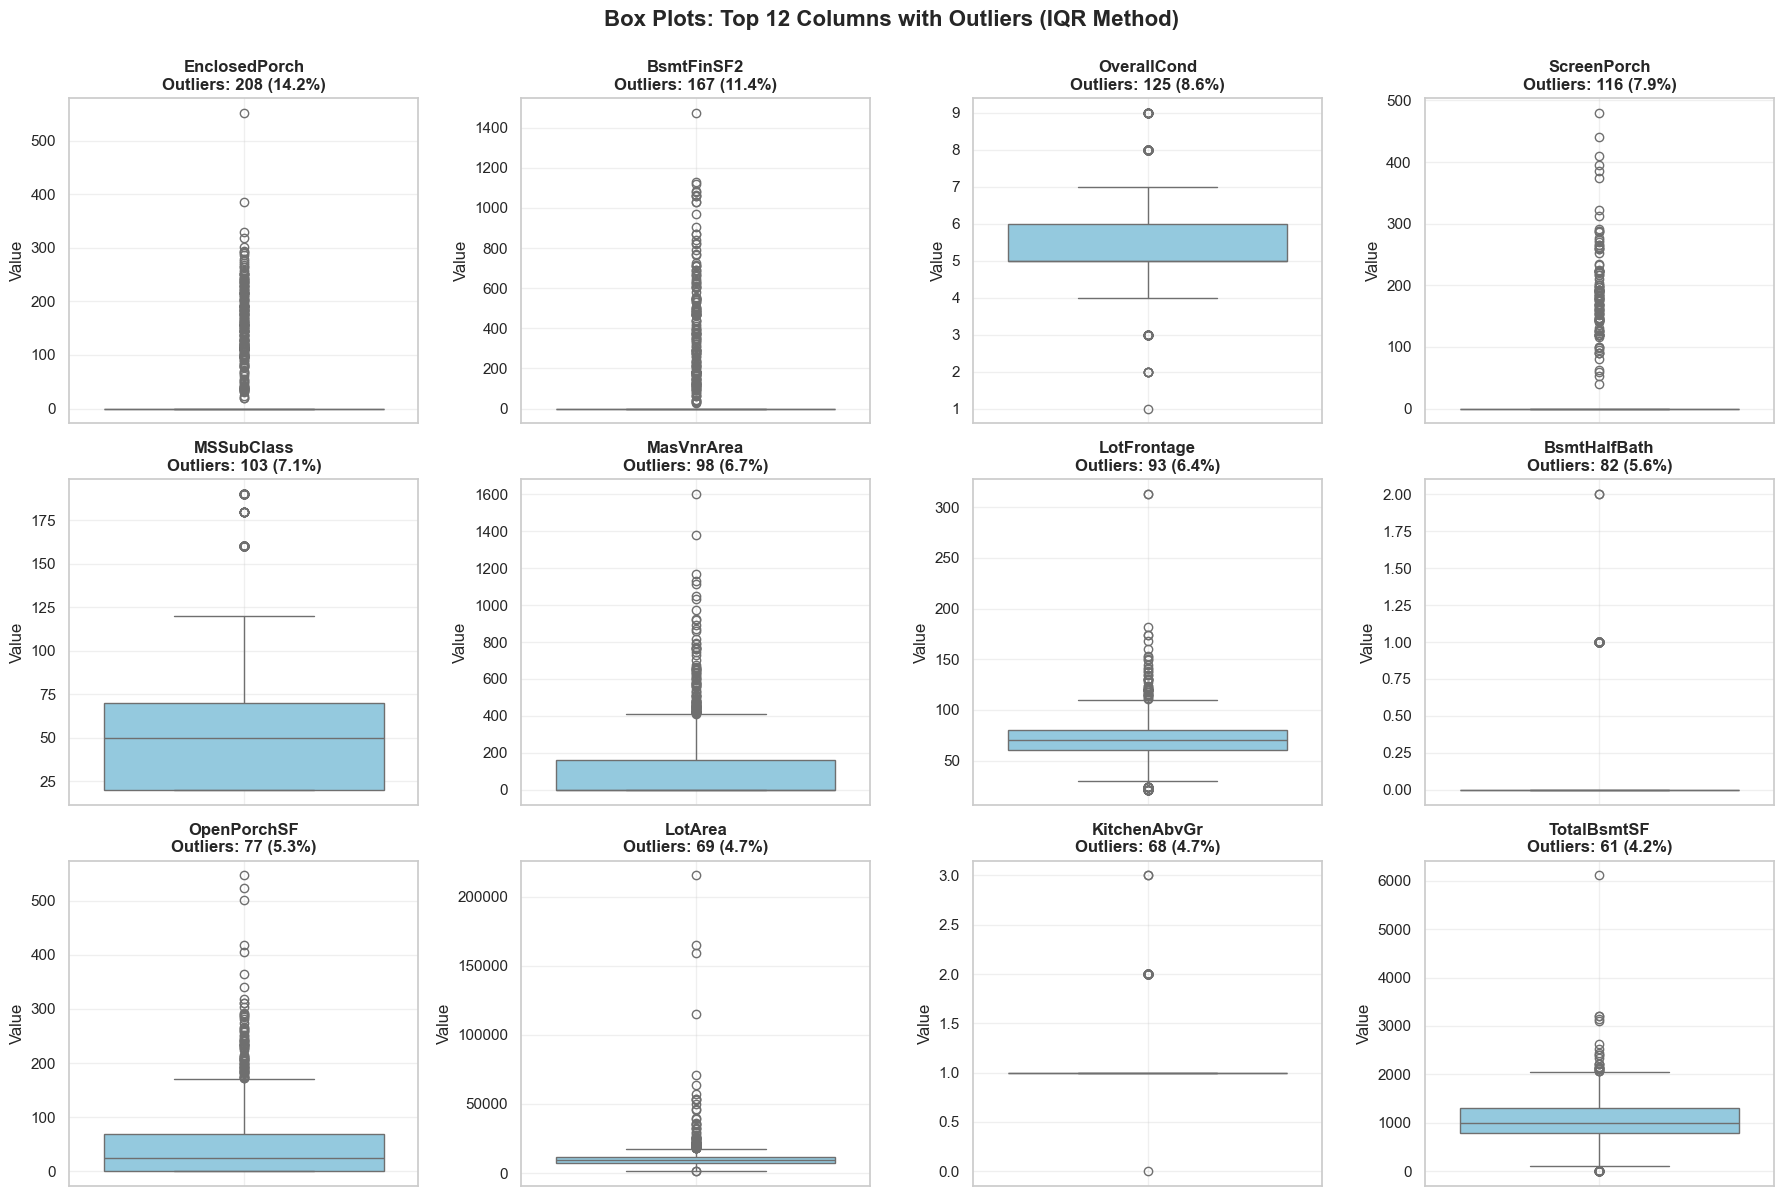

In [62]:
# Get top 12 columns with most outliers
top_outlier_cols = sorted(outliers_iqr.items(), key=lambda x: x[1]['count'], reverse=True)[:12]
top_cols = [col for col, _ in top_outlier_cols]

# Create box plots
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(top_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='skyblue')
    outlier_count = outliers_iqr[col]['count']
    outlier_pct = outliers_iqr[col]['percentage']
    
    axes[idx].set_title(f"{col}\nOutliers: {outlier_count} ({outlier_pct:.1f}%)", fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Box Plots: Top 12 Columns with Outliers (IQR Method)", 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Detailed Analysis: Target Variable (SalePrice)

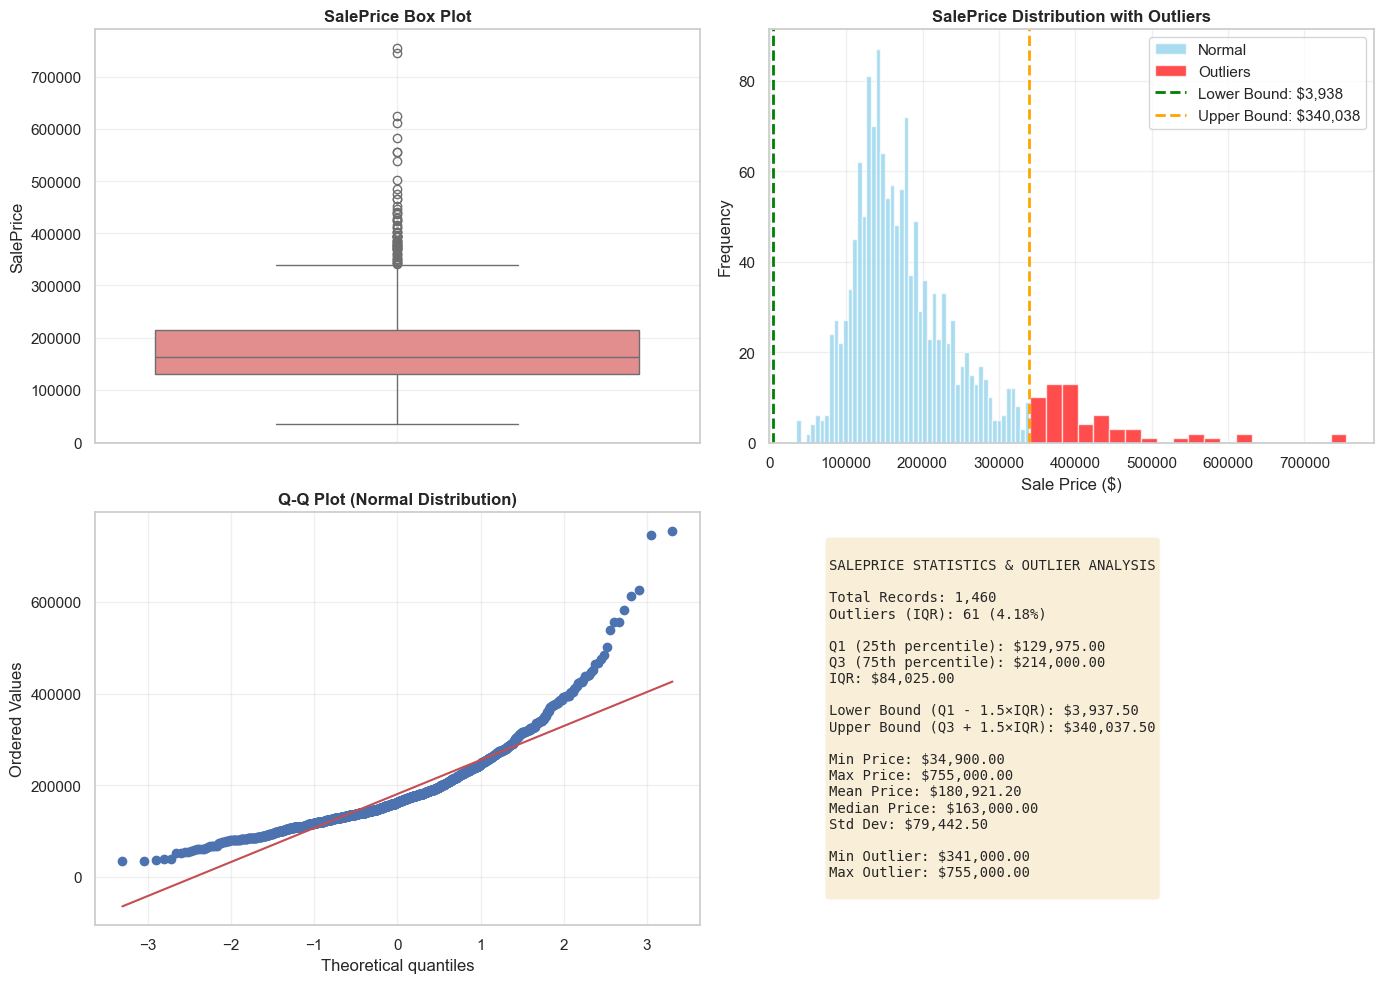


SALEPRICE STATISTICS & OUTLIER ANALYSIS

Total Records: 1,460
Outliers (IQR): 61 (4.18%)

Q1 (25th percentile): $129,975.00
Q3 (75th percentile): $214,000.00
IQR: $84,025.00

Lower Bound (Q1 - 1.5×IQR): $3,937.50
Upper Bound (Q3 + 1.5×IQR): $340,037.50

Min Price: $34,900.00
Max Price: $755,000.00
Mean Price: $180,921.20
Median Price: $163,000.00
Std Dev: $79,442.50

Min Outlier: $341,000.00
Max Outlier: $755,000.00



In [63]:
# Detailed analysis of SalePrice outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plot
sns.boxplot(y=df['SalePrice'], ax=axes[0, 0], color='lightcoral')
axes[0, 0].set_title('SalePrice Box Plot', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution with outliers highlighted
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)
axes[0, 1].hist(df.loc[~outlier_mask, 'SalePrice'], bins=50, alpha=0.7, label='Normal', color='skyblue')
axes[0, 1].hist(df.loc[outlier_mask, 'SalePrice'], bins=20, alpha=0.7, label='Outliers', color='red')
axes[0, 1].axvline(lower_bound, color='green', linestyle='--', linewidth=2, label=f'Lower Bound: ${lower_bound:,.0f}')
axes[0, 1].axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Bound: ${upper_bound:,.0f}')
axes[0, 1].set_title('SalePrice Distribution with Outliers', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Sale Price ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot
from scipy.stats import probplot
probplot(df['SalePrice'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal Distribution)', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# 4. Statistics table
stats_text = f"""
SALEPRICE STATISTICS & OUTLIER ANALYSIS

Total Records: {len(df):,}
Outliers (IQR): {outlier_mask.sum()} ({(outlier_mask.sum()/len(df)*100):.2f}%)

Q1 (25th percentile): ${Q1:,.2f}
Q3 (75th percentile): ${Q3:,.2f}
IQR: ${IQR:,.2f}

Lower Bound (Q1 - 1.5×IQR): ${lower_bound:,.2f}
Upper Bound (Q3 + 1.5×IQR): ${upper_bound:,.2f}

Min Price: ${df['SalePrice'].min():,.2f}
Max Price: ${df['SalePrice'].max():,.2f}
Mean Price: ${df['SalePrice'].mean():,.2f}
Median Price: ${df['SalePrice'].median():,.2f}
Std Dev: ${df['SalePrice'].std():,.2f}

Min Outlier: ${df.loc[outlier_mask, 'SalePrice'].min():,.2f}
Max Outlier: ${df.loc[outlier_mask, 'SalePrice'].max():,.2f}
"""

axes[1, 1].text(0.1, 0.5, stats_text, fontfamily='monospace', fontsize=10,
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(stats_text)


#### Conclusion
   This is a NATURALLY SKEWED dataset - EXPECTED for housing data:
   
   1. Right-skew is normal (market has outlier luxury properties)
   2. Heavy tails are realistic (few extremely large/expensive homes)
   3. Concentration patterns make sense (common features, rare special features)
   4. Spikes correspond to logical categories (no garage, no basement, etc.)

## Univariate Analysis


In [64]:
df["SalePrice"].skew()

np.float64(1.8828757597682129)

skewness > 0, (1.882) which mean the house price distribution is right skewed. Some expensive houses stretch the tail to the right  

In [65]:
df["LotArea"].value_counts()

LotArea
7200      25
9600      24
6000      17
10800     14
9000      14
8400      14
1680      10
7500       9
6120       8
6240       8
9100       8
8125       8
3182       7
8450       6
7800       6
4500       5
10400      5
5400       5
5000       5
10140      5
4435       5
10000      5
9750       5
11250      4
8500       4
8544       4
9375       4
10625      4
7018       4
8520       4
7000       4
8640       4
11700      4
9900       4
8750       4
13125      4
6600       4
8800       4
14115      3
9200       3
10200      3
10440      3
7750       3
10500      3
2522       3
13891      3
2117       3
2280       3
12090      3
8012       3
8000       3
11600      3
9084       3
6762       3
3675       3
9120       3
8777       3
4426       3
8712       3
9920       3
7875       3
11500      3
10084      2
10382      2
7420       2
11200      2
13695      2
7560       2
4224       2
2645       2
11645      2
13072      2
9591       2
10206      2
8892       2
7758       2
9525

common house size range from 7200 to the 9600 sq feet

In [66]:
df["BedroomAbvGr"].mode()

0    3
Name: BedroomAbvGr, dtype: int64

most common bedroom in a house are 3

In [67]:
df["YearBuilt"].value_counts()

YearBuilt
2006    67
2005    64
2004    54
2007    49
2003    45
1976    33
1977    32
1920    30
1959    26
1999    25
1998    25
2000    24
1965    24
1970    24
1958    24
1954    24
2002    23
1972    23
2008    23
1968    22
1971    22
2001    20
1957    20
1950    20
1962    19
1994    19
1966    18
1995    18
2009    18
1940    18
1993    17
1960    17
1910    17
1967    16
1955    16
1963    16
1925    16
1978    16
1964    15
1941    15
1996    15
1997    14
1956    14
1948    14
1961    14
1969    14
1992    13
1953    12
1990    12
1949    12
1973    11
1988    11
1915    10
1900    10
1980    10
1974    10
1930     9
1979     9
1936     9
1984     9
1926     9
1939     8
1975     8
1916     8
1922     8
1923     7
1924     7
1918     7
1928     7
1946     7
1914     7
1931     6
1951     6
1921     6
1945     6
1982     6
1935     6
1981     5
1991     5
1985     5
1952     5
1986     5
1947     5
1937     5
1929     4
1983     4
1932     4
1880     4
1938     4
1927     3


most of the house are old, built before 2006

## Correlation Analysis

## Bivariate Analysis: Features Positively Correlated with SalePrice



In [68]:
# Calculate correlation with SalePrice for numeric features
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlations = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

# Filter positive correlations (excluding SalePrice itself)
positive_corr = correlations[(correlations > 0) & (correlations.index != 'SalePrice')]

print("=" * 70)
print("FEATURES WITH POSITIVE CORRELATION TO SALEPRICE")
print("=" * 70)
print(f"\nTotal positive features: {len(positive_corr)}\n")

for idx, (feature, corr_value) in enumerate(positive_corr.items(), 1):
    strength = "Very Strong" if corr_value > 0.7 else "Strong" if corr_value > 0.5 else "Moderate" if corr_value > 0.3 else "Weak"
    print(f"{idx:2d}. {feature:20s} → {corr_value:7.4f}  ({strength})")


FEATURES WITH POSITIVE CORRELATION TO SALEPRICE

Total positive features: 27

 1. OverallQual          →  0.7910  (Very Strong)
 2. GrLivArea            →  0.7086  (Very Strong)
 3. GarageCars           →  0.6404  (Strong)
 4. GarageArea           →  0.6234  (Strong)
 5. TotalBsmtSF          →  0.6136  (Strong)
 6. 1stFlrSF             →  0.6059  (Strong)
 7. FullBath             →  0.5607  (Strong)
 8. TotRmsAbvGrd         →  0.5337  (Strong)
 9. YearBuilt            →  0.5229  (Strong)
10. GarageYrBlt          →  0.5080  (Strong)
11. YearRemodAdd         →  0.5071  (Strong)
12. MasVnrArea           →  0.4726  (Moderate)
13. Fireplaces           →  0.4669  (Moderate)
14. BsmtFinSF1           →  0.3864  (Moderate)
15. LotFrontage          →  0.3499  (Moderate)
16. WoodDeckSF           →  0.3244  (Moderate)
17. 2ndFlrSF             →  0.3193  (Moderate)
18. OpenPorchSF          →  0.3159  (Moderate)
19. HalfBath             →  0.2841  (Weak)
20. LotArea              →  0.2638  (Weak)
21

these are weak relationship that effect less to the sale price

In [69]:
numeric_cols = df.select_dtypes(include=["Float64", "int64"]).columns
correlations = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
negative_corr = correlations[(correlations < 0) & (correlations.index != 'SalePrice') & (correlations.index != 'Id')]

negative_corr

BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

- TotRmsAbvGrd: sum of bedroomAbvGr, fullBath, HalfBath, KitchenAbvGr

## Market Segmentation Analysis

Identify housing market segments: Budget, Mid-Market, and Luxury


In [70]:
# Define market segments using price and key characteristics
# Using price tertiles as primary segmentation

price_33 = df['SalePrice'].quantile(0.33)  # Budget/Mid boundary
price_67 = df['SalePrice'].quantile(0.67)  # Mid/Luxury boundary

def assign_segment(row):
    if row['SalePrice'] <= price_33:
        return 'Budget'
    elif row['SalePrice'] <= price_67:
        return 'Mid-Market'
    else:
        return 'Luxury'

df['Segment'] = df.apply(assign_segment, axis=1)

# Analyze segments
print("=" * 80)
print("MARKET SEGMENTATION ANALYSIS")
print("=" * 80)

segments_summary = df.groupby('Segment').agg({
    'SalePrice': ['count', 'min', 'max', 'mean', 'median'],
    'GrLivArea': 'mean',
    'OverallQual': 'mean',
    'GarageCars': 'mean',
    'TotalBsmtSF': 'mean',
    'YearBuilt': 'mean',
    'FullBath': 'mean'
}).round(2)

print("\nSegment Summary Statistics:")
print(segments_summary)

print("\n" + "=" * 80)
print("SEGMENT BREAKDOWN:")
print("=" * 80)

for segment in ['Budget', 'Mid-Market', 'Luxury']:
    segment_data = df[df['Segment'] == segment]
    count = len(segment_data)
    pct = (count / len(df)) * 100
    price_range = f"${segment_data['SalePrice'].min():,.0f} - ${segment_data['SalePrice'].max():,.0f}"
    avg_price = f"${segment_data['SalePrice'].mean():,.0f}"
    avg_size = f"{segment_data['GrLivArea'].mean():,.0f} sq ft"
    avg_quality = f"{segment_data['OverallQual'].mean():.1f}/10"
    
    print(f"\n📊 {segment.upper()}")
    print(f"   Count: {count} homes ({pct:.1f}%)")
    print(f"   Price Range: {price_range}")
    print(f"   Avg Price: {avg_price}")
    print(f"   Avg Size: {avg_size}")
    print(f"   Avg Quality: {avg_quality}")
    print(f"   Avg Full Baths: {segment_data['FullBath'].mean():.1f}")
    print(f"   Avg Garage Spaces: {segment_data['GarageCars'].mean():.1f}")


MARKET SEGMENTATION ANALYSIS

Segment Summary Statistics:
           SalePrice                                      GrLivArea  \
               count     min     max       mean    median      mean   
Segment                                                               
Budget           483   34900  139000  112871.36  118500.0   1152.38   
Luxury           479  192000  755000  267525.61  243000.0   1955.41   
Mid-Market       498  139400  191000  163621.11  163250.0   1444.45   

           OverallQual GarageCars TotalBsmtSF YearBuilt FullBath  
                  mean       mean        mean      mean     mean  
Segment                                                           
Budget            4.91       1.18      797.83   1948.24     1.18  
Luxury            7.42       2.33     1360.49   1992.15     1.97  
Mid-Market        5.98       1.80     1017.71   1973.52     1.55  

SEGMENT BREAKDOWN:

📊 BUDGET
   Count: 483 homes (33.1%)
   Price Range: $34,900 - $139,000
   Avg Price: $112,8

## EDA Report

- i've use Ames housing dataset, target variable was SalePrice. This dataset had **total 1460 records and 81 features** but after cleaning the data we have **1460 records and 77 features**. Overall data quality was 80-85% 
- These columns **PoolQC          99.520548,
MiscFeature     96.301370,
Alley           93.767123,
Fence           80.753425,
MasVnrType      59.726027** have much missing values filling them doesn't help in better prediction so decided to drop them.
- These are **FireplaceQu     47.260274,
GarageQual       5.547945,
GarageFinish     5.547945,
GarageType       5.547945,
GarageYrBlt      5.547945,
GarageCond       5.547945** moderate columns filled all them with "None" which indicates not available and for **LotFrontage     17.739726** filled each and every row with the median of it specific neighborhood because often houses in specific neighborhood have similar lotFrontage
- Price distribution is right skewed, mean most houses lies on the left but some luxury houses pull tail to the right
- OverallQual, GrLivArea are appear most strongest with have over 0.7 correlation with SalePrice 

In [ ]:
# df.to_csv("../data/preprocessed/ames_house_prices_cleaned.csv", index=False)